In [7]:
import os
import ipyleaflet
from PIL import Image
import requests
import math
from concurrent.futures import ThreadPoolExecutor
import io
import leafmap
from samgeo import SamGeo, show_image, download_file, overlay_images, tms_to_geotiff
import matplotlib.pyplot as plt

In [3]:
m = leafmap.Map(center=[23.0084671,72.5670317], zoom=19,min_zoom=19, max_zoom=19)
m.add_basemap("SATELLITE")
m.zoom_control = False
m.interactive = False

In [4]:
m

Map(center=[23.0084671, 72.5670317], controls=(AttributionControl(options=['position', 'prefix'], position='bo…

In [5]:
print(m.bounds)

((23.007727383973023, 72.5652900338173), (23.009208682870973, 72.56877154111864))


In [6]:
def toImage(m):

    # Bounds and zoom of the current view
    (latmin, lonmin), (latmax, lonmax) = m.bounds
    zoom = m.zoom

    # URLs of all the Tilelayer on the map
    baseUrls = [x.url for x in m.layers if isinstance(x, ipyleaflet.leaflet.TileLayer)]

    # Opacities
    opacities = [x.opacity for x in m.layers if isinstance(x, ipyleaflet.leaflet.TileLayer)]

    # Convert lat/lon/zoom to xtile, ytile.
    def latlon2tile(lat_deg, lon_deg, zoom):
        lat_rad = (lat_deg * math.pi) / 180.0
        n = math.pow(2, zoom)
        xtile = n * ((lon_deg + 180.0) / 360.0)
        ytile = n * (1 - (math.log(math.tan(lat_rad) + 1.0 / math.cos(lat_rad)) / math.pi)) / 2
        return xtile, ytile

    xtile1f, ytile2f = latlon2tile(latmin, lonmin, zoom)
    xtile2f, ytile1f = latlon2tile(latmax, lonmax, zoom)

    xtile1 = int(xtile1f)
    xtile2 = int(xtile2f)
    ytile1 = int(ytile1f)
    ytile2 = int(ytile2f)

    # Amount of pixels to crop on each side
    dx1 = 256 * (xtile1f - xtile1)
    dx2 = 256 * (xtile2 + 1 - xtile2f)
    dy1 = 256 * (ytile1f - ytile1)
    dy2 = 256 * (ytile2 + 1 - ytile2f)

    dx1 = round(dx1 * 100) // 100
    dx2 = round(dx2 * 100) // 100
    dy1 = round(dy1 * 100) // 100
    dy2 = round(dy2 * 100) // 100

    # Number of tiles
    nx = xtile2 - xtile1 + 1
    ny = ytile2 - ytile1 + 1

    # Dimension of the overall image
    w = 256 * nx
    h = 256 * ny
    imageTotal = Image.new(mode="RGBA", size=(w, h))

    # Substitute x,y,z into a TileService URL
    def url(baseurl, x, y, zoom):
        return baseurl.replace('{x}', str(int(x))).replace('{y}', str(int(y))).replace('{z}', str(int(zoom)))

    # Fetch and process each tile
    def fetch_tile(x, y):
        xpos = (x - xtile1) * 256
        ypos = (y - ytile1) * 256
        for baseurl, opacity in zip(baseUrls, opacities):
            try:
                image = Image.open(requests.get(url(baseurl, x, y, zoom), stream=True).raw)
                image = image.convert('RGBA')

                if opacity < 1.0:
                    # Split image in 4 channels
                    (r, g, b, a) = image.split()

                    # Change the alpha channel
                    a = Image.eval(a, lambda px: opacity * px)

                    # Merge 4 channels
                    image = Image.merge('RGBA', (r, g, b, a))

                # Transparent paste!!!
                imageTotal.paste(image, (xpos, ypos), mask=image)
            except:
                pass

    # Create a ThreadPoolExecutor to download tiles in parallel
    with ThreadPoolExecutor() as executor:
        futures = []
        for x in range(xtile1, xtile2 + 1):
            for y in range(ytile1, ytile2 + 1):
                futures.append(executor.submit(fetch_tile, x, y))

        # Wait for all tiles to be processed
        for future in futures:
            future.result()

    # Crop the image
    area_crop = (dx1, dy1, w - dx2, h - dy2)
    return imageTotal.crop(area_crop)

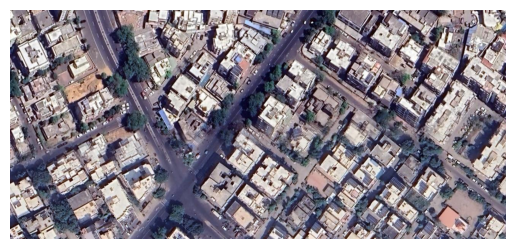

In [10]:
img = toImage(m)
img = img.convert("RGB")
plt.imshow(img)
plt.axis('off')
plt.show()
# exporting the image
img.save("/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/Demo_images/sample_1.jpg")